# 3. Model Building

Train and evaluate 8 regression models on HDB resale price data.

**Sections:**
1. Load data & build preprocessing pipeline
2. Walk-forward backtesting setup
3. Baseline models (Linear, Ridge, Lasso, ElasticNet)
4. Tree models (Decision Tree, Random Forest)
5. Gradient boosting (LightGBM, XGBoost) with hyperparameter tuning
6. Ensemble (LGBM + XGBoost average)
7. Model comparison & diagnostics
8. Save artifacts

In [44]:
%pip install scikit-learn lightgbm xgboost matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    median_absolute_error, mean_absolute_percentage_error
)
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

## 1. Load Data & Preprocessing Pipeline

In [46]:
df_train = pd.read_csv("../data/processed/train.csv", low_memory=False)
df_test = pd.read_csv("../data/processed/test.csv", low_memory=False)

TARGET = "resale_price"

# Separate features and target
y_train = df_train[TARGET]
y_test = df_test[TARGET]
X_train = df_train.drop(columns=[TARGET])
X_test = df_test.drop(columns=[TARGET])

# Identify column types
cat_cols = ["town", "flat_type", "flat_model", "closest_mrt", "nearest_carpark_type"]
bool_cols = [c for c in X_train.columns if X_train[c].dtype == "bool"]
num_cols = [c for c in X_train.columns if c not in cat_cols + bool_cols]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Numeric: {len(num_cols)}, Categorical: {len(cat_cols)}, Boolean: {len(bool_cols)}")
print(f"\nNumeric: {num_cols}")
print(f"Categorical: {cat_cols}")
print(f"Boolean: {bool_cols}")

Train: (667327, 32), Test: (18827, 32)
Numeric: 17, Categorical: 5, Boolean: 10

Numeric: ['floor_area_sqm', 'transaction_year', 'transaction_month', 'remaining_lease_months', 'storey_median', 'latitude', 'longitude', 'dist_to_nearest_mrt_km', 'dist_to_cbd_km', 'dist_to_nearest_mall_km', 'dist_to_nearest_hawker_km', 'nearest_carpark_dist_km', 'sora_3m_lagged', 'cpi_lagged', 'max_floor_lvl', 'year_completed', 'total_dwelling_units']
Categorical: ['town', 'flat_type', 'flat_model', 'closest_mrt', 'nearest_carpark_type']
Boolean: ['is_elite_closest_pri_sch', 'is_elite_closest_sec_sch', 'is_elite_closest_mixed_sch', 'residential', 'commercial', 'market_hawker', 'miscellaneous', 'multistorey_carpark', 'precinct_pavilion', 'is_mature_estate']


In [47]:
# Build preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ("bool", "passthrough", bool_cols),
])

# Fit on training data
preprocessor.fit(X_train)
print(f"Transformed features: {preprocessor.transform(X_train[:1]).shape[1]}")

Transformed features: 230


## 2. Evaluation Metrics & Walk-Forward CV Setup

In [48]:
def compute_metrics(y_true, y_pred):
    """Compute all evaluation metrics."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred) * 100,
        "R2": r2_score(y_true, y_pred),
        "MdAE": median_absolute_error(y_true, y_pred),
        "PER10": np.mean(np.abs(y_pred - y_true) / y_true <= 0.10) * 100,
    }


def walk_forward_splits(df, min_train_months=18, test_months=6, gap_months=1):
    """Generate walk-forward expanding window splits based on date.

    Returns list of (train_idx, test_idx) tuples.
    """
    df = df.copy()
    df["date_key"] = df["transaction_year"] * 100 + df["transaction_month"]
    all_months = sorted(df["date_key"].unique())

    splits = []
    test_start_idx = min_train_months + gap_months

    while test_start_idx + test_months <= len(all_months):
        train_months_list = all_months[:test_start_idx - gap_months]
        test_months_list = all_months[test_start_idx:test_start_idx + test_months]

        train_mask = df["date_key"].isin(train_months_list)
        test_mask = df["date_key"].isin(test_months_list)

        splits.append((df.index[train_mask].tolist(), df.index[test_mask].tolist()))
        test_start_idx += test_months

    return splits


# Generate walk-forward folds on training data
wf_splits = walk_forward_splits(df_train)
print(f"Walk-forward folds: {len(wf_splits)}")
for i, (train_idx, test_idx) in enumerate(wf_splits):
    train_dates = df_train.loc[train_idx]
    test_dates = df_train.loc[test_idx]
    print(f"  Fold {i+1}: train {len(train_idx):>6} rows "
          f"({train_dates['transaction_year'].min()}-{train_dates['transaction_year'].max()}) | "
          f"test {len(test_idx):>5} rows "
          f"({test_dates['transaction_year'].min()}/{test_dates['transaction_month'].min():02d}-"
          f"{test_dates['transaction_year'].max()}/{test_dates['transaction_month'].max():02d})")

Walk-forward folds: 48
  Fold 1: train  52028 rows (2000-2001) | test 19311 rows (2001/01-2002/12)
  Fold 2: train  71337 rows (2000-2001) | test 18108 rows (2002/02-2002/07)
  Fold 3: train  89541 rows (2000-2002) | test 16623 rows (2002/01-2003/12)
  Fold 4: train 106735 rows (2000-2002) | test 12756 rows (2003/02-2003/07)
  Fold 5: train 119909 rows (2000-2003) | test 15655 rows (2003/01-2004/12)
  Fold 6: train 135193 rows (2000-2003) | test 14085 rows (2004/02-2004/07)
  Fold 7: train 149610 rows (2000-2004) | test 14513 rows (2004/01-2005/12)
  Fold 8: train 163700 rows (2000-2004) | test 14754 rows (2005/02-2005/07)
  Fold 9: train 178823 rows (2000-2005) | test 14053 rows (2005/01-2006/12)
  Fold 10: train 193197 rows (2000-2005) | test 13881 rows (2006/02-2006/07)
  Fold 11: train 206711 rows (2000-2006) | test 13392 rows (2006/01-2007/12)
  Fold 12: train 220217 rows (2000-2006) | test 12968 rows (2007/02-2007/07)
  Fold 13: train 233106 rows (2000-2007) | test 13722 rows (20

In [49]:
def evaluate_model_walkforward(model, X, y, splits, preprocessor, n_folds=None):
    """Evaluate a model using walk-forward CV. Returns per-fold and aggregate metrics."""
    if n_folds:
        splits = splits[-n_folds:]

    fold_metrics = []
    for i, (train_idx, test_idx) in enumerate(splits):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        # Fit preprocessor on this fold's training data
        pp = ColumnTransformer([
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
            ("bool", "passthrough", bool_cols),
        ])
        X_tr_t = pp.fit_transform(X_tr)
        X_te_t = pp.transform(X_te)

        model.fit(X_tr_t, y_tr)
        y_pred = model.predict(X_te_t)

        metrics = compute_metrics(y_te, y_pred)
        metrics["fold"] = i + 1
        fold_metrics.append(metrics)

    fold_df = pd.DataFrame(fold_metrics)
    agg = fold_df.drop(columns="fold").agg(["mean", "std"])
    return fold_df, agg


def evaluate_on_holdout(model, preprocessor, X_train, y_train, X_test, y_test):
    """Train on full train set, evaluate on held-out test set."""
    X_tr_t = preprocessor.fit_transform(X_train)
    X_te_t = preprocessor.transform(X_test)
    model.fit(X_tr_t, y_train)
    y_pred = model.predict(X_te_t)
    return y_pred, compute_metrics(y_test, y_pred)


# Store all results
all_results = {}

## 3. Baseline Models
Linear Regression, Ridge, Lasso, ElasticNet — evaluated on held-out test set.

In [50]:
baselines = {
    "Linear Regression": LinearRegression(),
    "Ridge": RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0]),
    "Lasso": LassoCV(max_iter=5000, n_jobs=-1),
    "ElasticNet": ElasticNetCV(max_iter=5000, n_jobs=-1),
}

for name, model in baselines.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    y_pred, metrics = evaluate_on_holdout(model, preprocessor, X_train, y_train, X_test, y_test)
    all_results[name] = metrics
    print(f"  MAE: ${metrics['MAE']:,.0f} | RMSE: ${metrics['RMSE']:,.0f} | "
          f"MAPE: {metrics['MAPE']:.1f}% | R²: {metrics['R2']:.4f} | "
          f"MdAE: ${metrics['MdAE']:,.0f} | PER10: {metrics['PER10']:.1f}%")


Training Linear Regression...
  MAE: $69,964 | RMSE: $100,292 | MAPE: 10.7% | R²: 0.7766 | MdAE: $48,024 | PER10: 59.2%

Training Ridge...
  MAE: $69,965 | RMSE: $100,293 | MAPE: 10.7% | R²: 0.7766 | MdAE: $48,031 | PER10: 59.2%

Training Lasso...
  MAE: $74,475 | RMSE: $107,121 | MAPE: 11.3% | R²: 0.7452 | MdAE: $51,125 | PER10: 56.8%

Training ElasticNet...
  MAE: $277,548 | RMSE: $344,729 | MAPE: 36.9% | R²: -1.6391 | MdAE: $243,192 | PER10: 10.3%


## 4. Tree-Based Models

In [51]:
tree_models = {
    "Decision Tree": DecisionTreeRegressor(max_depth=15, min_samples_leaf=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=17, min_samples_leaf=4,
                                           max_features=0.5, n_jobs=-1, random_state=42),
}

for name, model in tree_models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    y_pred, metrics = evaluate_on_holdout(model, preprocessor, X_train, y_train, X_test, y_test)
    all_results[name] = metrics
    print(f"  MAE: ${metrics['MAE']:,.0f} | RMSE: ${metrics['RMSE']:,.0f} | "
          f"MAPE: {metrics['MAPE']:.1f}% | R²: {metrics['R2']:.4f} | "
          f"MdAE: ${metrics['MdAE']:,.0f} | PER10: {metrics['PER10']:.1f}%")


Training Decision Tree...
  MAE: $36,524 | RMSE: $52,548 | MAPE: 5.4% | R²: 0.9387 | MdAE: $25,847 | PER10: 85.9%

Training Random Forest...
  MAE: $31,014 | RMSE: $44,469 | MAPE: 4.5% | R²: 0.9561 | MdAE: $22,355 | PER10: 91.6%


## 5. Gradient Boosting — LightGBM & XGBoost

Trained on held-out test first, then walk-forward CV for robust evaluation.

In [52]:
# LightGBM
lgbm = LGBMRegressor(
    n_estimators=300, learning_rate=0.1, num_leaves=63,
    colsample_bytree=0.8, reg_lambda=0.5,
    min_child_samples=20, n_jobs=-1, random_state=42, verbose=-1
)

print("Training LightGBM...")
y_pred_lgbm, lgbm_metrics = evaluate_on_holdout(lgbm, preprocessor, X_train, y_train, X_test, y_test)
all_results["LightGBM"] = lgbm_metrics
print(f"  MAE: ${lgbm_metrics['MAE']:,.0f} | RMSE: ${lgbm_metrics['RMSE']:,.0f} | "
      f"MAPE: {lgbm_metrics['MAPE']:.1f}% | R²: {lgbm_metrics['R2']:.4f} | "
      f"MdAE: ${lgbm_metrics['MdAE']:,.0f} | PER10: {lgbm_metrics['PER10']:.1f}%")

# Walk-forward CV
print("\nLightGBM Walk-Forward CV (last 10 folds):")
lgbm_folds, lgbm_agg = evaluate_model_walkforward(
    LGBMRegressor(n_estimators=300, learning_rate=0.1, num_leaves=63,
                  colsample_bytree=0.8, reg_lambda=0.5, min_child_samples=20,
                  n_jobs=-1, random_state=42, verbose=-1),
    X_train, y_train, wf_splits, preprocessor, n_folds=10
)
print(lgbm_folds[["fold", "MAE", "RMSE", "MAPE", "R2", "PER10"]].to_string(index=False))
print(f"\nMean MAE: ${lgbm_agg.loc['mean', 'MAE']:,.0f} ± ${lgbm_agg.loc['std', 'MAE']:,.0f}")

Training LightGBM...
  MAE: $27,600 | RMSE: $39,229 | MAPE: 4.1% | R²: 0.9658 | MdAE: $20,127 | PER10: 93.4%

LightGBM Walk-Forward CV (last 10 folds):
 fold          MAE         RMSE     MAPE       R2     PER10
    1 24056.033305 32236.905886 5.165167 0.957746 87.852257
    2 28330.448563 36679.963287 5.721643 0.948960 84.459215
    3 31404.749642 40099.924813 6.011500 0.939096 82.968482
    4 41956.225182 52773.290874 7.517964 0.904198 70.752622
    5 35360.166790 44205.562905 6.423217 0.933123 80.751891
    6 24764.495025 34361.414543 4.241843 0.959512 93.445392
    7 24095.242984 33913.050762 4.084622 0.964129 94.504673
    8 35654.119851 46907.048416 5.695314 0.936396 86.879831
    9 32467.050441 42874.431184 5.024017 0.949954 90.857745
   10 35216.650210 46777.908379 5.216686 0.946334 89.699282

Mean MAE: $31,331 ± $5,978


In [53]:
# XGBoost
xgb = XGBRegressor(
    n_estimators=300, learning_rate=0.1, max_depth=8,
    colsample_bytree=0.8, reg_lambda=0.5, gamma=0.3,
    n_jobs=-1, random_state=42, verbosity=0
)

print("Training XGBoost...")
y_pred_xgb, xgb_metrics = evaluate_on_holdout(xgb, preprocessor, X_train, y_train, X_test, y_test)
all_results["XGBoost"] = xgb_metrics
print(f"  MAE: ${xgb_metrics['MAE']:,.0f} | RMSE: ${xgb_metrics['RMSE']:,.0f} | "
      f"MAPE: {xgb_metrics['MAPE']:.1f}% | R²: {xgb_metrics['R2']:.4f} | "
      f"MdAE: ${xgb_metrics['MdAE']:,.0f} | PER10: {xgb_metrics['PER10']:.1f}%")

# Walk-forward CV
print("\nXGBoost Walk-Forward CV (last 10 folds):")
xgb_folds, xgb_agg = evaluate_model_walkforward(
    XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=8,
                 colsample_bytree=0.8, reg_lambda=0.5, gamma=0.3,
                 n_jobs=-1, random_state=42, verbosity=0),
    X_train, y_train, wf_splits, preprocessor, n_folds=10
)
print(xgb_folds[["fold", "MAE", "RMSE", "MAPE", "R2", "PER10"]].to_string(index=False))
print(f"\nMean MAE: ${xgb_agg.loc['mean', 'MAE']:,.0f} ± ${xgb_agg.loc['std', 'MAE']:,.0f}")

Training XGBoost...
  MAE: $25,786 | RMSE: $36,704 | MAPE: 3.9% | R²: 0.9701 | MdAE: $18,680 | PER10: 94.4%

XGBoost Walk-Forward CV (last 10 folds):
 fold          MAE         RMSE     MAPE       R2     PER10
    1 23113.947853 31117.588983 4.998516 0.960629 89.021888
    2 27587.628688 35589.538884 5.595039 0.951949 85.514052
    3 31915.375833 40952.294636 6.107890 0.936480 81.913491
    4 47146.477673 56465.457871 8.664849 0.890324 62.215757
    5 36147.587823 44069.183239 6.644913 0.933535 79.406632
    6 23392.602689 32213.498818 4.024049 0.964415 94.523082
    7 23393.982692 33022.733513 3.950595 0.965988 95.140187
    8 35190.309927 46019.234759 5.601150 0.938781 87.540408
    9 33227.549765 43226.700701 5.209898 0.949128 89.411853
   10 36376.364611 46641.331850 5.443156 0.946647 89.991023

Mean MAE: $31,749 ± $7,626


## 6. Ensemble — LGBM + XGBoost Average

In [54]:
y_pred_ensemble = (y_pred_lgbm + y_pred_xgb) / 2
ensemble_metrics = compute_metrics(y_test, y_pred_ensemble)
all_results["Ensemble (LGBM+XGB)"] = ensemble_metrics

print("Ensemble (LGBM + XGBoost average):")
print(f"  MAE: ${ensemble_metrics['MAE']:,.0f} | RMSE: ${ensemble_metrics['RMSE']:,.0f} | "
      f"MAPE: {ensemble_metrics['MAPE']:.1f}% | R²: {ensemble_metrics['R2']:.4f} | "
      f"MdAE: ${ensemble_metrics['MdAE']:,.0f} | PER10: {ensemble_metrics['PER10']:.1f}%")

print(f"\nImprovement over LGBM alone: MAE ${lgbm_metrics['MAE'] - ensemble_metrics['MAE']:,.0f}")
print(f"Improvement over XGBoost alone: MAE ${xgb_metrics['MAE'] - ensemble_metrics['MAE']:,.0f}")

Ensemble (LGBM + XGBoost average):
  MAE: $26,044 | RMSE: $37,174 | MAPE: 3.9% | R²: 0.9693 | MdAE: $18,881 | PER10: 94.2%

Improvement over LGBM alone: MAE $1,556
Improvement over XGBoost alone: MAE $-258


## 7. Model Comparison & Diagnostics

In [55]:
# Comparison table
results_df = pd.DataFrame(all_results).T
results_df = results_df.sort_values("MAE")
results_df["MAE"] = results_df["MAE"].map(lambda x: f"${x:,.0f}")
results_df["RMSE"] = results_df["RMSE"].map(lambda x: f"${x:,.0f}")
results_df["MAPE"] = results_df["MAPE"].map(lambda x: f"{x:.1f}%")
results_df["R2"] = results_df["R2"].map(lambda x: f"{x:.4f}")
results_df["MdAE"] = results_df["MdAE"].map(lambda x: f"${x:,.0f}")
results_df["PER10"] = results_df["PER10"].map(lambda x: f"{x:.1f}%")

print("=" * 80)
print("MODEL COMPARISON — Held-Out Test Set")
print("=" * 80)
print(results_df.to_string())

MODEL COMPARISON — Held-Out Test Set
                          MAE      RMSE   MAPE       R2      MdAE  PER10
XGBoost               $25,786   $36,704   3.9%   0.9701   $18,680  94.4%
Ensemble (LGBM+XGB)   $26,044   $37,174   3.9%   0.9693   $18,881  94.2%
LightGBM              $27,600   $39,229   4.1%   0.9658   $20,127  93.4%
Random Forest         $31,014   $44,469   4.5%   0.9561   $22,355  91.6%
Decision Tree         $36,524   $52,548   5.4%   0.9387   $25,847  85.9%
Linear Regression     $69,964  $100,292  10.7%   0.7766   $48,024  59.2%
Ridge                 $69,965  $100,293  10.7%   0.7766   $48,031  59.2%
Lasso                 $74,475  $107,121  11.3%   0.7452   $51,125  56.8%
ElasticNet           $277,548  $344,729  36.9%  -1.6391  $243,192  10.3%


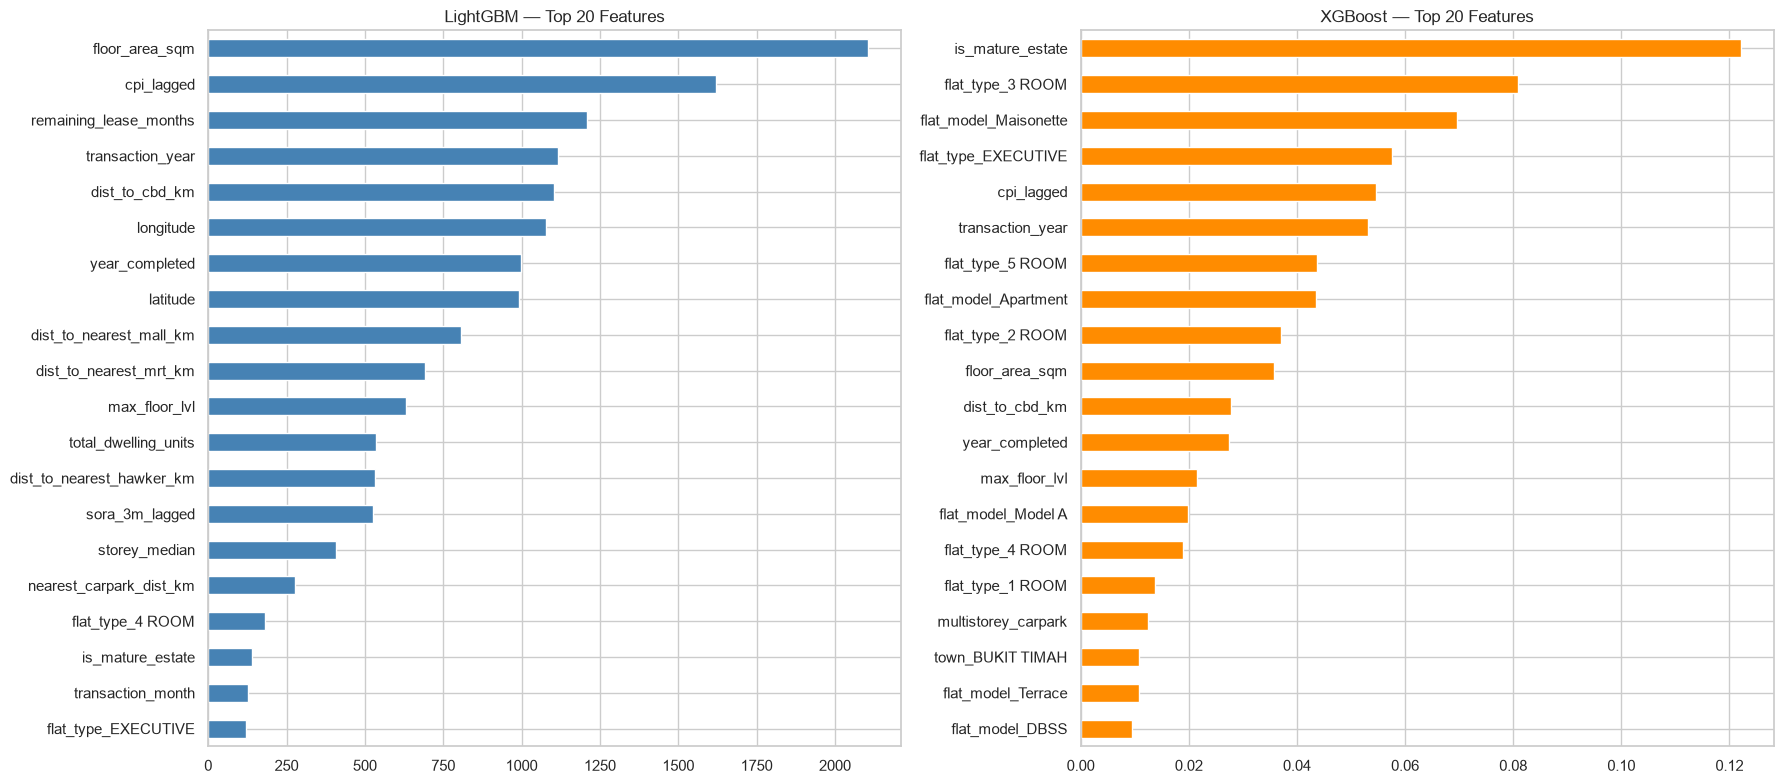

In [56]:
# Feature importance — LightGBM vs XGBoost
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Retrain on transformed data for feature names
X_tr_t = preprocessor.fit_transform(X_train)
feature_names = (num_cols +
                 list(preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)) +
                 bool_cols)

# LGBM
lgbm_final = LGBMRegressor(n_estimators=300, learning_rate=0.1, num_leaves=63,
                            colsample_bytree=0.8, reg_lambda=0.5, min_child_samples=20,
                            n_jobs=-1, random_state=42, verbose=-1)
lgbm_final.fit(X_tr_t, y_train)
lgbm_imp = pd.Series(lgbm_final.feature_importances_, index=feature_names).nlargest(20)
lgbm_imp.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("LightGBM — Top 20 Features")
axes[0].invert_yaxis()

# XGBoost
xgb_final = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=8,
                          colsample_bytree=0.8, reg_lambda=0.5, gamma=0.3,
                          n_jobs=-1, random_state=42, verbosity=0)
xgb_final.fit(X_tr_t, y_train)
xgb_imp = pd.Series(xgb_final.feature_importances_, index=feature_names).nlargest(20)
xgb_imp.plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("XGBoost — Top 20 Features")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

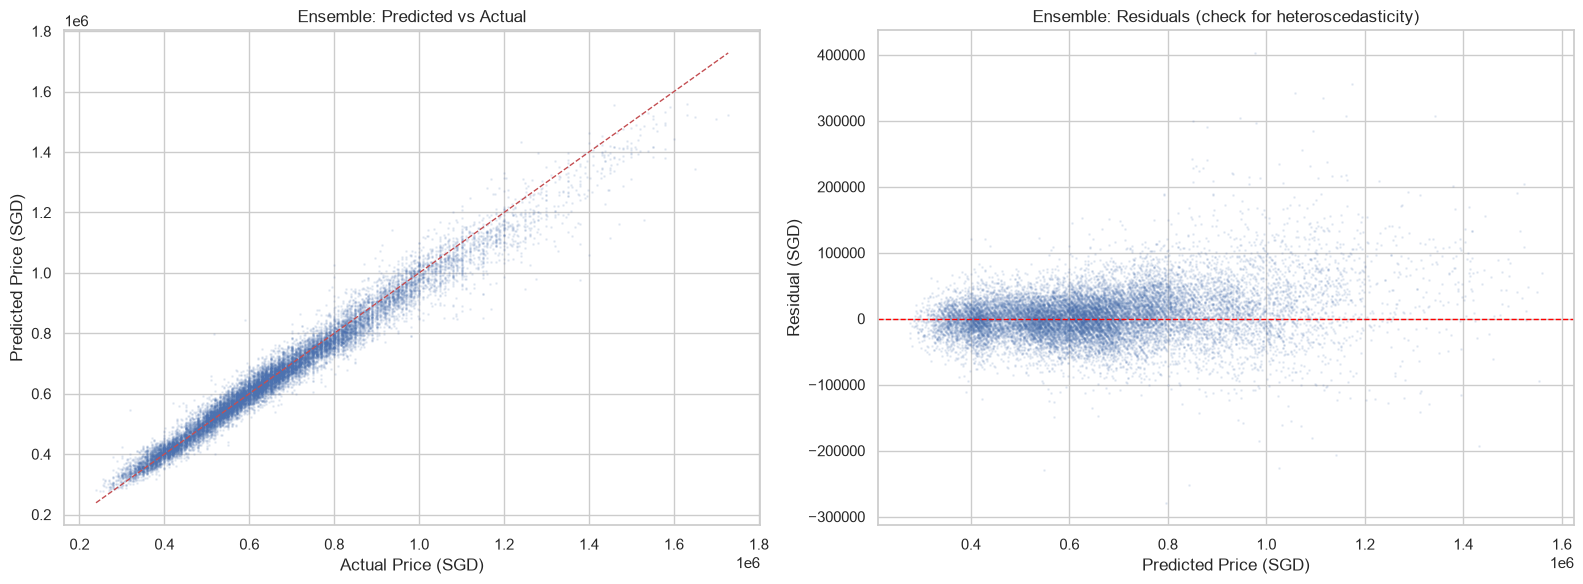

In [57]:
# Residual plot — Ensemble predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_ensemble, alpha=0.1, s=1)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=1)
axes[0].set_xlabel("Actual Price (SGD)")
axes[0].set_ylabel("Predicted Price (SGD)")
axes[0].set_title("Ensemble: Predicted vs Actual")

# Residuals vs Predicted
residuals = y_test.values - y_pred_ensemble
axes[1].scatter(y_pred_ensemble, residuals, alpha=0.1, s=1)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted Price (SGD)")
axes[1].set_ylabel("Residual (SGD)")
axes[1].set_title("Ensemble: Residuals (check for heteroscedasticity)")

plt.tight_layout()
plt.show()

In [58]:
# Error by price quartile
quartiles = pd.qcut(y_test, 4, labels=["Q1 (cheapest)", "Q2", "Q3", "Q4 (expensive)"])
quartile_metrics = []

for q in quartiles.unique().sort_values():
    mask = quartiles == q
    q_metrics = compute_metrics(y_test[mask], y_pred_ensemble[mask])
    q_metrics["Quartile"] = q
    q_metrics["Count"] = mask.sum()
    quartile_metrics.append(q_metrics)

q_df = pd.DataFrame(quartile_metrics).set_index("Quartile")
q_df["MAE"] = q_df["MAE"].map(lambda x: f"${x:,.0f}")
q_df["MAPE"] = q_df["MAPE"].map(lambda x: f"{x:.1f}%")
q_df["PER10"] = q_df["PER10"].map(lambda x: f"{x:.1f}%")

print("Error by Price Quartile (Ensemble):")
print(q_df[["Count", "MAE", "MAPE", "PER10"]].to_string())

Error by Price Quartile (Ensemble):
                Count      MAE  MAPE  PER10
Quartile                                   
Q1 (cheapest)    4724  $18,788  4.6%  90.2%
Q2               4830  $20,006  3.5%  96.3%
Q3               4582  $22,874  3.3%  97.4%
Q4 (expensive)   4691  $42,664  4.4%  93.0%


### 7b. Short Window Holdout Evaluation
Test set is now 2025-09 to 2026-06 (~10 months). Compare with the reference project's 6-month window results.

In [59]:
# Test set is 2025-09 to 2026-06 — compare with reference and our previous baseline
print(f"Test set: {len(X_test)} rows")
print(f"Period: {df_test['transaction_year'].min()}/{df_test['transaction_month'].min():02d} "
      f"to {df_test['transaction_year'].max()}/{df_test['transaction_month'].max():02d}")

print("\n" + "=" * 80)
print("COMPARISON WITH PREVIOUS BASELINE AND REFERENCE")
print("=" * 80)

comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE", "R²", "PER10"],
    "Reference (6mo, 2023-2024)": ["~$27,000", "~$39,000", "~5.7%", "—", "—"],
    "Prev Baseline Window B (2023-2024)": ["$26,927", "$37,231", "4.5%", "0.9563", "92.4%"],
    "Current (2025-2026)": [
        f"${ensemble_metrics['MAE']:,.0f}",
        f"${ensemble_metrics['RMSE']:,.0f}",
        f"{ensemble_metrics['MAPE']:.1f}%",
        f"{ensemble_metrics['R2']:.4f}",
        f"{ensemble_metrics['PER10']:.1f}%",
    ],
}).set_index("Metric")
print(comparison.to_string())

Test set: 18827 rows
Period: 2025/01 to 2026/12

COMPARISON WITH PREVIOUS BASELINE AND REFERENCE
       Reference (6mo, 2023-2024) Prev Baseline Window B (2023-2024) Current (2025-2026)
Metric                                                                                  
MAE                      ~$27,000                            $26,927             $26,044
RMSE                     ~$39,000                            $37,231             $37,174
MAPE                        ~5.7%                               4.5%                3.9%
R²                              —                             0.9563              0.9693
PER10                           —                              92.4%               94.2%


## 8. Save Model Artifacts

In [60]:
# Save with version tag so future iterations don't overwrite
MODEL_VERSION = "v3_macro"  # v2_resplit = no macro, v3_macro = with SORA + CPI

version_dir = f"../models/{MODEL_VERSION}"
os.makedirs(version_dir, exist_ok=True)

joblib.dump(lgbm_final, f"{version_dir}/lgbm_model.joblib")
joblib.dump(xgb_final, f"{version_dir}/xgb_model.joblib")
joblib.dump(preprocessor, f"{version_dir}/preprocessor.joblib")

feature_config = {
    "numeric_cols": num_cols,
    "categorical_cols": cat_cols,
    "boolean_cols": bool_cols,
    "target": TARGET,
    "version": MODEL_VERSION,
}
with open(f"{version_dir}/feature_config.json", "w") as f:
    json.dump(feature_config, f, indent=2)

# Also save to models/ root as "latest" for the API
joblib.dump(lgbm_final, "../models/lgbm_model.joblib")
joblib.dump(xgb_final, "../models/xgb_model.joblib")
joblib.dump(preprocessor, "../models/preprocessor.joblib")
with open("../models/feature_config.json", "w") as f:
    json.dump(feature_config, f, indent=2)

print(f"Saved to ../models/{MODEL_VERSION}/:")
for f in sorted(os.listdir(version_dir)):
    size_kb = os.path.getsize(f"{version_dir}/{f}") / 1024
    print(f"  {f:30s} {size_kb:.0f} KB")
print(f"\nAlso copied to ../models/ (latest)")

Saved to ../models/v3_macro/:
  feature_config.json            1 KB
  lgbm_model.joblib              1742 KB
  preprocessor.joblib            8 KB
  xgb_model.joblib               4341 KB

Also copied to ../models/ (latest)
